# 68 - SigLIP 2 Large 384 ONNX 評価（Python vs JS）

## 概要
SigLIP 2 **Large 384** (`google/siglip2-large-patch16-384`) の ONNX モデルを
Transformers.js (Node.js) で実行し、Python (PyTorch) との互換性を評価する。

## 背景
- Notebook 67: SigLIP 2 Large **256** の ONNX 評価を実施
  - fp16 は fp32 と実質同一、テキスト埋め込み完全一致、JA MRR 1.000
- 384 版は入力解像度が 256→384 に拡大。画像の細部をより捉えられる可能性

## 評価項目
1. **画像埋め込み: Python vs JS コサイン類似度**（fp32, fp16, q8, q4）
2. **テキスト埋め込み: Python vs JS コサイン類似度**（EN + JA）
3. **テキスト→画像検索 MRR: Python vs JS**（18 クエリ）
4. **256 vs 384 の比較**

## モデル情報
| 項目 | 値 |
|------|-----|
| Python | `google/siglip2-large-patch16-384` |
| ONNX | `onnx-community/siglip2-large-patch16-384-ONNX` |
| 次元 | 1024 |
| 解像度 | 384x384 |

In [1]:
import json
import os
import subprocess
import tempfile
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance

from image_vector_poc import SigLIP2Embedder

## 1. 環境設定

In [2]:
# nvm の Node.js パスを追加
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js version: {result.stdout.strip()}")

# パス設定
DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../js")
PYTHON_MODEL = "google/siglip2-large-patch16-384"
JS_MODEL = "onnx-community/siglip2-large-patch16-384-ONNX"
EMBEDDING_DIM = 1024

Node.js version: v24.13.1


## 2. 画像カタログの読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)
catalog_df = conn.execute("""
    SELECT id, file_path, category FROM image_catalog ORDER BY id
""").fetchdf()
conn.close()

print(f"Images: {len(catalog_df)}")
print(f"Categories: {catalog_df['category'].nunique()}")

Images: 378
Categories: 6


## 3. Python 画像埋め込み生成

In [4]:
from PIL import Image
import time

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device="cuda")
print(f"Model: {embedder.model_name}")
print(f"Embedding dim: {embedder.embedding_dim}")

# バッチ処理で画像埋め込みを生成
BATCH_SIZE = 32
all_images = []
valid_ids = []

for _, row in catalog_df.iterrows():
    try:
        img = Image.open(row["file_path"]).convert("RGB")
        all_images.append(img)
        valid_ids.append(row["id"])
    except Exception as e:
        print(f"Error loading {row['file_path']}: {e}")

print(f"Loaded {len(all_images)} images")

start_time = time.time()
all_embeddings = []
for i in range(0, len(all_images), BATCH_SIZE):
    batch = all_images[i:i+BATCH_SIZE]
    batch_emb = embedder.embed_images(batch)
    all_embeddings.append(batch_emb)

py_embeddings_array = np.concatenate(all_embeddings, axis=0)
elapsed = time.time() - start_time

print(f"Python embeddings shape: {py_embeddings_array.shape}")
print(f"Processing time: {elapsed:.1f}s ({len(all_images)/elapsed:.1f} img/s)")

# ID → 埋め込み辞書
py_embeddings = {vid: py_embeddings_array[i] for i, vid in enumerate(valid_ids)}

config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Model: google/siglip2-large-patch16-384
Embedding dim: 1024


Loaded 378 images


Python embeddings shape: (378, 1024)
Processing time: 61.6s (6.1 img/s)


## 4. JS 画像埋め込み生成（4 dtype）

In [5]:
# JS スクリプト用の画像リスト JSON
image_list = [{"id": row["id"], "file_path": row["file_path"]} for _, row in catalog_df.iterrows()]
image_list_path = Path(tempfile.mktemp(suffix=".json"))
with open(image_list_path, "w") as f:
    json.dump(image_list, f)

print(f"Image list: {len(image_list)} images")

dtypes = ["fp32", "fp16", "q8", "q4"]
js_results = {}

for dtype in dtypes:
    print(f"\n{'='*50}")
    print(f"Running JS embedding with dtype={dtype}...")
    print(f"{'='*50}")
    
    output_path = Path(tempfile.mktemp(suffix=f"_large384_{dtype}.json"))
    
    cmd = [
        "node", str(JS_DIR / "embed_images_siglip2.mjs"),
        "--image-list", str(image_list_path),
        "--output", str(output_path),
        "--dtype", dtype,
        "--model", JS_MODEL,
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
    print(result.stderr[-500:] if len(result.stderr) > 500 else result.stderr)
    
    if result.returncode != 0:
        print(f"ERROR: JS process failed with return code {result.returncode}")
        continue
    
    with open(output_path) as f:
        js_output = json.load(f)
    
    js_results[dtype] = js_output
    print(f"  Model: {js_output['model']}")
    print(f"  Count: {js_output['count']}")
    print(f"  Time: {js_output['processing_time_seconds']}s")
    
    output_path.unlink(missing_ok=True)

image_list_path.unlink(missing_ok=True)
print(f"\n\nCompleted dtypes: {list(js_results.keys())}")

Image list: 378 images

Running JS embedding with dtype=fp32...


80/378] 297.5s elapsed (0.9 img/s)
  [290/378] 308.1s elapsed (0.9 img/s)
  [300/378] 318.3s elapsed (0.9 img/s)
  [310/378] 329.3s elapsed (0.9 img/s)
  [320/378] 340.9s elapsed (0.9 img/s)
  [330/378] 351.4s elapsed (0.9 img/s)
  [340/378] 361.8s elapsed (0.9 img/s)
  [350/378] 372.2s elapsed (0.9 img/s)
  [360/378] 382.8s elapsed (0.9 img/s)
  [370/378] 393.9s elapsed (0.9 img/s)
  [378/378] 403.2s elapsed (0.9 img/s)
Done. 378 embeddings saved to /tmp/tmpt142wr8h_large384_fp32.json (403.2s)

  Model: onnx-community/siglip2-large-patch16-384-ONNX
  Count: 378
  Time: 403.2s

Running JS embedding with dtype=fp16...


80/378] 422.5s elapsed (0.7 img/s)
  [290/378] 436.3s elapsed (0.7 img/s)
  [300/378] 449.8s elapsed (0.7 img/s)
  [310/378] 464.3s elapsed (0.7 img/s)
  [320/378] 478.3s elapsed (0.7 img/s)
  [330/378] 492.8s elapsed (0.7 img/s)
  [340/378] 507.4s elapsed (0.7 img/s)
  [350/378] 521.8s elapsed (0.7 img/s)
  [360/378] 538.2s elapsed (0.7 img/s)
  [370/378] 552.3s elapsed (0.7 img/s)
  [378/378] 564.2s elapsed (0.7 img/s)
Done. 378 embeddings saved to /tmp/tmpoowjwsoc_large384_fp16.json (564.2s)

  Model: onnx-community/siglip2-large-patch16-384-ONNX
  Count: 378
  Time: 564.2s

Running JS embedding with dtype=q8...


[280/378] 240.3s elapsed (1.2 img/s)
  [290/378] 248.7s elapsed (1.2 img/s)
  [300/378] 257.2s elapsed (1.2 img/s)
  [310/378] 265.9s elapsed (1.2 img/s)
  [320/378] 274.2s elapsed (1.2 img/s)
  [330/378] 283.8s elapsed (1.2 img/s)
  [340/378] 292.6s elapsed (1.2 img/s)
  [350/378] 302.5s elapsed (1.2 img/s)
  [360/378] 311.6s elapsed (1.2 img/s)
  [370/378] 321.2s elapsed (1.2 img/s)
  [378/378] 328.2s elapsed (1.2 img/s)
Done. 378 embeddings saved to /tmp/tmp5a2qnp46_large384_q8.json (328.2s)

  Model: onnx-community/siglip2-large-patch16-384-ONNX
  Count: 378
  Time: 328.2s

Running JS embedding with dtype=q4...


[280/378] 367.1s elapsed (0.8 img/s)
  [290/378] 380.3s elapsed (0.8 img/s)
  [300/378] 393.4s elapsed (0.8 img/s)
  [310/378] 406.5s elapsed (0.8 img/s)
  [320/378] 419.7s elapsed (0.8 img/s)
  [330/378] 432.6s elapsed (0.8 img/s)
  [340/378] 445.8s elapsed (0.8 img/s)
  [350/378] 458.8s elapsed (0.8 img/s)
  [360/378] 472.4s elapsed (0.8 img/s)
  [370/378] 485.8s elapsed (0.8 img/s)
  [378/378] 496.7s elapsed (0.8 img/s)
Done. 378 embeddings saved to /tmp/tmpox550f8u_large384_q4.json (496.7s)

  Model: onnx-community/siglip2-large-patch16-384-ONNX
  Count: 378
  Time: 496.7s


Completed dtypes: ['fp32', 'fp16', 'q8', 'q4']


## 5. 画像埋め込み: Python vs JS コサイン類似度

In [6]:
comparison_results = {}

for dtype, js_output in js_results.items():
    js_embeddings = {item['id']: np.array(item['embedding'], dtype=np.float32)
                     for item in js_output['embeddings']}
    
    similarities = []
    for image_id in py_embeddings:
        if image_id in js_embeddings:
            py_emb = py_embeddings[image_id]
            js_emb = js_embeddings[image_id]
            if np.any(js_emb != 0):  # skip zero placeholders
                sim = 1.0 - cosine_distance(py_emb, js_emb)
                similarities.append(sim)
    
    sims = np.array(similarities)
    comparison_results[dtype] = {
        'mean': float(sims.mean()),
        'std': float(sims.std()),
        'min': float(sims.min()),
        'max': float(sims.max()),
        'median': float(np.median(sims)),
        'count': len(sims),
        'processing_time': js_output['processing_time_seconds'],
    }

print("=" * 80)
print("Python vs JS 画像埋め込みコサイン類似度 (SigLIP 2 Large 384)")
print("=" * 80)

print(f"\n{'dtype':<8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8} {'Time(s)':>10}")
print("-" * 62)
for dtype, r in comparison_results.items():
    print(f"{dtype:<8} {r['mean']:>8.4f} {r['std']:>8.4f} {r['min']:>8.4f} {r['max']:>8.4f} {r['median']:>8.4f} {r['processing_time']:>10.1f}")

print(f"\n--- Large 256 の結果（参考）---")
print(f"256 fp32: mean=0.912, fp16: 0.912, q8: 0.856, q4: 0.902")
print(f"--- Base の結果（参考）---")
print(f"Base fp32: mean=0.924, fp16: 0.924, q8: 0.750(破損), q4: 0.902")

Python vs JS 画像埋め込みコサイン類似度 (SigLIP 2 Large 384)

dtype        Mean      Std      Min      Max   Median    Time(s)
--------------------------------------------------------------
fp32       0.9272   0.0279   0.7855   0.9975   0.9328      403.2
fp16       0.9272   0.0279   0.7853   0.9976   0.9328      564.2
q8         0.8644   0.0453   0.7199   0.9824   0.8690      328.2
q4         0.9140   0.0290   0.7654   0.9877   0.9193      496.7

--- Large 256 の結果（参考）---
256 fp32: mean=0.912, fp16: 0.912, q8: 0.856, q4: 0.902
--- Base の結果（参考）---
Base fp32: mean=0.924, fp16: 0.924, q8: 0.750(破損), q4: 0.902


## 6. 量子化の内部比較（JS fp32 vs 各 dtype）

In [7]:
if 'fp32' in js_results and len(js_results) >= 2:
    print("=" * 60)
    print("量子化の影響: fp32 vs 各 dtype（JS 内の比較）")
    print("=" * 60)
    
    fp32_embs = {item['id']: np.array(item['embedding'], dtype=np.float32)
                 for item in js_results['fp32']['embeddings']}
    
    quant_comparison = {}
    for dtype in ['fp16', 'q8', 'q4']:
        if dtype not in js_results:
            continue
        other_embs = {item['id']: np.array(item['embedding'], dtype=np.float32)
                     for item in js_results[dtype]['embeddings']}
        
        sims = []
        for img_id in fp32_embs:
            if img_id in other_embs and np.any(other_embs[img_id] != 0):
                sim = 1.0 - cosine_distance(fp32_embs[img_id], other_embs[img_id])
                sims.append(sim)
        
        sims = np.array(sims)
        quant_comparison[dtype] = {'mean': float(sims.mean()), 'std': float(sims.std()), 'min': float(sims.min())}
        print(f"  fp32 vs {dtype}: mean={sims.mean():.6f}, std={sims.std():.6f}, min={sims.min():.6f}")
    
    print(f"\n--- Large 256 の参考値 ---")
    print(f"  fp32 vs fp16: 1.000000")
    print(f"  fp32 vs q8:   0.918728")
    print(f"  fp32 vs q4:   0.979137")
else:
    print("Not enough dtype results for comparison.")
    quant_comparison = {}

量子化の影響: fp32 vs 各 dtype（JS 内の比較）


  fp32 vs fp16: mean=0.999998, std=0.000003, min=0.999949
  fp32 vs q8: mean=0.926408, std=0.034108, min=0.821964
  fp32 vs q4: mean=0.981807, std=0.007281, min=0.934712

--- Large 256 の参考値 ---
  fp32 vs fp16: 1.000000
  fp32 vs q8:   0.918728
  fp32 vs q4:   0.979137


## 7. テキスト埋め込み: Python vs JS コサイン類似度

In [8]:
# 18 クエリのテキスト
all_texts = [
    "a park with trees and nature",
    "village park with greenery",
    "night cityscape Tokyo",
    "city lights at night",
    "Python conference presentation",
    "conference hall with audience",
    "speaker giving a talk",
    "portrait photo of a person",
    "outdoor nature scene",
    "urban night photography",
    "tech conference event",
    "people at an event",
    "公園の自然風景",
    "東京の夜景",
    "カンファレンスの講演",
    "人物の写真",
    "緑の木々",
    "夜の街",
]

# Python テキスト埋め込み
py_text_embeddings = embedder.embed_texts(all_texts)
print(f"Python text embeddings shape: {py_text_embeddings.shape}")

Python text embeddings shape: (18, 1024)


In [9]:
# JS テキスト埋め込み (fp32)
texts_path = Path(tempfile.mktemp(suffix=".json"))
output_path = Path(tempfile.mktemp(suffix=".json"))

with open(texts_path, "w") as f:
    json.dump(all_texts, f, ensure_ascii=False)

cmd = [
    "node", str(JS_DIR / "embed_texts_siglip2.mjs"),
    "--texts", str(texts_path),
    "--output", str(output_path),
    "--dtype", "fp32",
    "--model", JS_MODEL,
]

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print("JS stderr:")
print(result.stderr)

js_text_output_fp32 = None
if result.returncode == 0:
    with open(output_path) as f:
        js_text_output_fp32 = json.load(f)
    print(f"JS text embeddings (fp32): {js_text_output_fp32['count']}")
else:
    print(f"ERROR: JS process failed")

texts_path.unlink(missing_ok=True)
output_path.unlink(missing_ok=True)

JS stderr:
Model: onnx-community/siglip2-large-patch16-384-ONNX
dtype: fp32
Texts to process: 18
Loading model and tokenizer...
Model loaded in 216.0s
Tokenizer type: GemmaTokenizer
  [10/18] 1.4s elapsed
  [18/18] 2.6s elapsed
Done. 18 text embeddings saved to /tmp/tmpl487a0aa.json (2.6s)

JS text embeddings (fp32): 18


In [10]:
# JS テキスト埋め込み (fp16)
texts_path = Path(tempfile.mktemp(suffix=".json"))
output_path = Path(tempfile.mktemp(suffix=".json"))

with open(texts_path, "w") as f:
    json.dump(all_texts, f, ensure_ascii=False)

cmd = [
    "node", str(JS_DIR / "embed_texts_siglip2.mjs"),
    "--texts", str(texts_path),
    "--output", str(output_path),
    "--dtype", "fp16",
    "--model", JS_MODEL,
]

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print("JS stderr:")
print(result.stderr)

js_text_output_fp16 = None
if result.returncode == 0:
    with open(output_path) as f:
        js_text_output_fp16 = json.load(f)
    print(f"JS text embeddings (fp16): {js_text_output_fp16['count']}")
else:
    print(f"ERROR: JS process failed")

texts_path.unlink(missing_ok=True)
output_path.unlink(missing_ok=True)

JS stderr:
Model: onnx-community/siglip2-large-patch16-384-ONNX
dtype: fp16
Texts to process: 18
Loading model and tokenizer...
Model loaded in 109.7s
Tokenizer type: GemmaTokenizer
  [10/18] 3.6s elapsed
  [18/18] 5.7s elapsed
Done. 18 text embeddings saved to /tmp/tmpcwlrj2vw.json (5.7s)

JS text embeddings (fp16): 18


In [11]:
# Python vs JS テキスト埋め込みのコサイン類似度
print("=" * 80)
print("Python vs JS テキスト埋め込み コサイン類似度 (Large 384)")
print("=" * 80)

text_sims_results = {}

for label, js_output in [("fp32", js_text_output_fp32), ("fp16", js_text_output_fp16)]:
    if js_output is None:
        continue
    
    text_sims = []
    print(f"\n--- {label} ---")
    for i, (text, js_item) in enumerate(zip(all_texts, js_output['embeddings'])):
        py_emb = py_text_embeddings[i]
        js_emb = np.array(js_item['embedding'], dtype=np.float32)
        sim = 1.0 - cosine_distance(py_emb, js_emb)
        
        is_ja = any(ord(c) > 0x3000 for c in text)
        lang = "JA" if is_ja else "EN"
        text_sims.append({'text': text, 'lang': lang, 'cosine_sim': sim})
        print(f"  [{lang}] {text[:40]:40s} | cos_sim = {sim:.6f}")
    
    text_sims_df = pd.DataFrame(text_sims)
    en_mean = text_sims_df[text_sims_df['lang']=='EN']['cosine_sim'].mean()
    ja_mean = text_sims_df[text_sims_df['lang']=='JA']['cosine_sim'].mean()
    print(f"\n  Summary: EN={en_mean:.6f}, JA={ja_mean:.6f}")
    text_sims_results[label] = {'en': en_mean, 'ja': ja_mean, 'all': text_sims_df['cosine_sim'].mean()}

print(f"\n--- Large 256 の参考値 ---")
print(f"  fp32: EN=1.000000, JA=1.000000")
print(f"  fp16: EN=1.000000, JA=1.000000")

Python vs JS テキスト埋め込み コサイン類似度 (Large 384)

--- fp32 ---
  [EN] a park with trees and nature             | cos_sim = 1.000000
  [EN] village park with greenery               | cos_sim = 1.000000
  [EN] night cityscape Tokyo                    | cos_sim = 1.000000
  [EN] city lights at night                     | cos_sim = 1.000000
  [EN] Python conference presentation           | cos_sim = 1.000000
  [EN] conference hall with audience            | cos_sim = 1.000000
  [EN] speaker giving a talk                    | cos_sim = 1.000000
  [EN] portrait photo of a person               | cos_sim = 1.000000
  [EN] outdoor nature scene                     | cos_sim = 1.000000
  [EN] urban night photography                  | cos_sim = 1.000000
  [EN] tech conference event                    | cos_sim = 1.000000
  [EN] people at an event                       | cos_sim = 1.000000
  [JA] 公園の自然風景                                  | cos_sim = 1.000000
  [JA] 東京の夜景                                   

## 8. テキスト→画像検索 MRR 比較

In [12]:
# テストクエリ定義
test_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "lang": "en"},
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
]

# 画像埋め込みを正規化
norms = np.linalg.norm(py_embeddings_array, axis=1, keepdims=True)
image_embeddings_norm = py_embeddings_array / np.clip(norms, 1e-8, None)
categories = catalog_df['category'].tolist()


def compute_search_mrr(text_embeddings, image_embeddings_norm, categories, test_queries):
    results = []
    for i, q in enumerate(test_queries):
        text_emb = text_embeddings[i]
        text_emb = text_emb / np.linalg.norm(text_emb)
        
        similarities = np.dot(image_embeddings_norm, text_emb)
        top_indices = np.argsort(similarities)[::-1][:20]
        result_cats = [categories[idx] for idx in top_indices]
        is_relevant = [cat in q['expected_categories'] for cat in result_cats]
        
        mrr = 0.0
        for j, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (j + 1)
                break
        
        p_at_1 = sum(is_relevant[:1])
        results.append({'query': q['query'], 'lang': q['lang'], 'MRR': mrr, 'P@1': p_at_1})
    
    return pd.DataFrame(results)

print(f"Image embeddings: {image_embeddings_norm.shape}")

Image embeddings: (378, 1024)


In [13]:
# Python テキスト検索
py_search_df = compute_search_mrr(py_text_embeddings, image_embeddings_norm, categories, test_queries)

print("Python テキスト検索結果:")
for _, row in py_search_df.iterrows():
    print(f"  [{row['lang'].upper()}] {row['query'][:35]:35s} | MRR={row['MRR']:.2f} | P@1={row['P@1']:.0f}")

print(f"\n全体 MRR: {py_search_df['MRR'].mean():.4f}")
print(f"EN MRR:   {py_search_df[py_search_df['lang']=='en']['MRR'].mean():.4f}")
print(f"JA MRR:   {py_search_df[py_search_df['lang']=='ja']['MRR'].mean():.4f}")

Python テキスト検索結果:
  [EN] a park with trees and nature        | MRR=0.50 | P@1=0
  [EN] village park with greenery          | MRR=0.20 | P@1=0
  [EN] night cityscape Tokyo               | MRR=1.00 | P@1=1
  [EN] city lights at night                | MRR=1.00 | P@1=1
  [EN] Python conference presentation      | MRR=1.00 | P@1=1
  [EN] conference hall with audience       | MRR=1.00 | P@1=1
  [EN] speaker giving a talk               | MRR=1.00 | P@1=1
  [EN] portrait photo of a person          | MRR=1.00 | P@1=1
  [EN] outdoor nature scene                | MRR=1.00 | P@1=1
  [EN] urban night photography             | MRR=1.00 | P@1=1
  [EN] tech conference event               | MRR=1.00 | P@1=1
  [EN] people at an event                  | MRR=1.00 | P@1=1
  [JA] 公園の自然風景                             | MRR=1.00 | P@1=1
  [JA] 東京の夜景                               | MRR=1.00 | P@1=1
  [JA] カンファレンスの講演                          | MRR=1.00 | P@1=1
  [JA] 人物の写真                               | MRR=1.00

In [14]:
# JS テキスト検索（fp32 と fp16）
js_search_results = {}

for label, js_output in [("fp32", js_text_output_fp32), ("fp16", js_text_output_fp16)]:
    if js_output is None:
        continue
    
    js_text_embs = np.array(
        [item['embedding'] for item in js_output['embeddings']],
        dtype=np.float32
    )
    
    js_search_df = compute_search_mrr(js_text_embs, image_embeddings_norm, categories, test_queries)
    
    print(f"\nJS テキスト検索結果 ({label}):")
    for _, row in js_search_df.iterrows():
        print(f"  [{row['lang'].upper()}] {row['query'][:35]:35s} | MRR={row['MRR']:.2f} | P@1={row['P@1']:.0f}")
    
    overall = js_search_df['MRR'].mean()
    en_mrr = js_search_df[js_search_df['lang']=='en']['MRR'].mean()
    ja_mrr = js_search_df[js_search_df['lang']=='ja']['MRR'].mean()
    
    print(f"\n全体 MRR: {overall:.4f}")
    print(f"EN MRR:   {en_mrr:.4f}")
    print(f"JA MRR:   {ja_mrr:.4f}")
    
    js_search_results[label] = {'Overall': overall, 'EN': en_mrr, 'JA': ja_mrr}


JS テキスト検索結果 (fp32):
  [EN] a park with trees and nature        | MRR=0.50 | P@1=0
  [EN] village park with greenery          | MRR=0.20 | P@1=0
  [EN] night cityscape Tokyo               | MRR=1.00 | P@1=1
  [EN] city lights at night                | MRR=1.00 | P@1=1
  [EN] Python conference presentation      | MRR=1.00 | P@1=1
  [EN] conference hall with audience       | MRR=1.00 | P@1=1
  [EN] speaker giving a talk               | MRR=1.00 | P@1=1
  [EN] portrait photo of a person          | MRR=1.00 | P@1=1
  [EN] outdoor nature scene                | MRR=1.00 | P@1=1
  [EN] urban night photography             | MRR=1.00 | P@1=1
  [EN] tech conference event               | MRR=1.00 | P@1=1
  [EN] people at an event                  | MRR=1.00 | P@1=1
  [JA] 公園の自然風景                             | MRR=1.00 | P@1=1
  [JA] 東京の夜景                               | MRR=1.00 | P@1=1
  [JA] カンファレンスの講演                          | MRR=1.00 | P@1=1
  [JA] 人物の写真                               | MRR=

## 9. 256 vs 384 比較

In [15]:
print("=" * 90)
print("SigLIP 2 Large: 256 vs 384 比較")
print("=" * 90)

# 256 の結果（Notebook 67 より）
results_256 = {
    "image_cos_sim": {"fp32": 0.9115, "fp16": 0.9115, "q8": 0.8559, "q4": 0.9016},
    "text_cos_sim": {"fp32": {"en": 1.0, "ja": 1.0}, "fp16": {"en": 1.0, "ja": 1.0}},
    "search_mrr": {"py": {"EN": 0.8917, "JA": 1.0, "Overall": 0.9278},
                   "js_fp32": {"EN": 0.8917, "JA": 1.0, "Overall": 0.9278},
                   "js_fp16": {"EN": 0.8917, "JA": 1.0, "Overall": 0.9278}},
    "speed": {"py_img_per_s": 6.8, "js_fp32_time": 209.6, "js_fp16_time": 293.8},
}

# 384 の結果（本ノートブック）
py_overall = py_search_df['MRR'].mean()
py_en = py_search_df[py_search_df['lang']=='en']['MRR'].mean()
py_ja = py_search_df[py_search_df['lang']=='ja']['MRR'].mean()

print(f"\n### 画像埋め込み: Python vs JS コサイン類似度")
print(f"{'dtype':<8} {'256':>10} {'384':>10} {'差分':>10}")
print("-" * 40)
for dtype in ['fp32', 'fp16', 'q8', 'q4']:
    v256 = results_256['image_cos_sim'].get(dtype, 0)
    v384 = comparison_results.get(dtype, {}).get('mean', 0)
    diff = v384 - v256
    print(f"{dtype:<8} {v256:>10.4f} {v384:>10.4f} {diff:>+10.4f}")

print(f"\n### テキスト埋め込み: Python vs JS コサイン類似度")
print(f"{'dtype':<8} {'256 EN':>8} {'384 EN':>8} {'256 JA':>8} {'384 JA':>8}")
print("-" * 40)
for dtype in ['fp32', 'fp16']:
    v256_en = results_256['text_cos_sim'].get(dtype, {}).get('en', 0)
    v256_ja = results_256['text_cos_sim'].get(dtype, {}).get('ja', 0)
    v384_en = text_sims_results.get(dtype, {}).get('en', 0)
    v384_ja = text_sims_results.get(dtype, {}).get('ja', 0)
    print(f"{dtype:<8} {v256_en:>8.4f} {v384_en:>8.4f} {v256_ja:>8.4f} {v384_ja:>8.4f}")

print(f"\n### テキスト→画像検索 MRR")
print(f"{'環境':<25} {'256 EN':>8} {'384 EN':>8} {'256 JA':>8} {'384 JA':>8} {'256 All':>8} {'384 All':>8}")
print("-" * 80)
print(f"{'Python':<25} {0.8917:>8.4f} {py_en:>8.4f} {1.0:>8.4f} {py_ja:>8.4f} {0.9278:>8.4f} {py_overall:>8.4f}")
for label in ['fp32', 'fp16']:
    if label in js_search_results:
        v256 = results_256['search_mrr'].get(f'js_{label}', {})
        v384 = js_search_results[label]
        print(f"{'JS ' + label:<25} {v256.get('EN', 0):>8.4f} {v384['EN']:>8.4f} {v256.get('JA', 0):>8.4f} {v384['JA']:>8.4f} {v256.get('Overall', 0):>8.4f} {v384['Overall']:>8.4f}")

SigLIP 2 Large: 256 vs 384 比較

### 画像埋め込み: Python vs JS コサイン類似度
dtype           256        384         差分
----------------------------------------
fp32         0.9115     0.9272    +0.0157
fp16         0.9115     0.9272    +0.0157
q8           0.8559     0.8644    +0.0085
q4           0.9016     0.9140    +0.0124

### テキスト埋め込み: Python vs JS コサイン類似度
dtype      256 EN   384 EN   256 JA   384 JA
----------------------------------------
fp32       1.0000   1.0000   1.0000   1.0000
fp16       1.0000   1.0000   1.0000   1.0000

### テキスト→画像検索 MRR
環境                          256 EN   384 EN   256 JA   384 JA  256 All  384 All
--------------------------------------------------------------------------------
Python                      0.8917   0.8917   1.0000   0.9167   0.9278   0.9000
JS fp32                     0.8917   0.8917   1.0000   0.9167   0.9278   0.9000
JS fp16                     0.8917   0.8917   1.0000   0.9167   0.9278   0.9000


## 10. 可視化

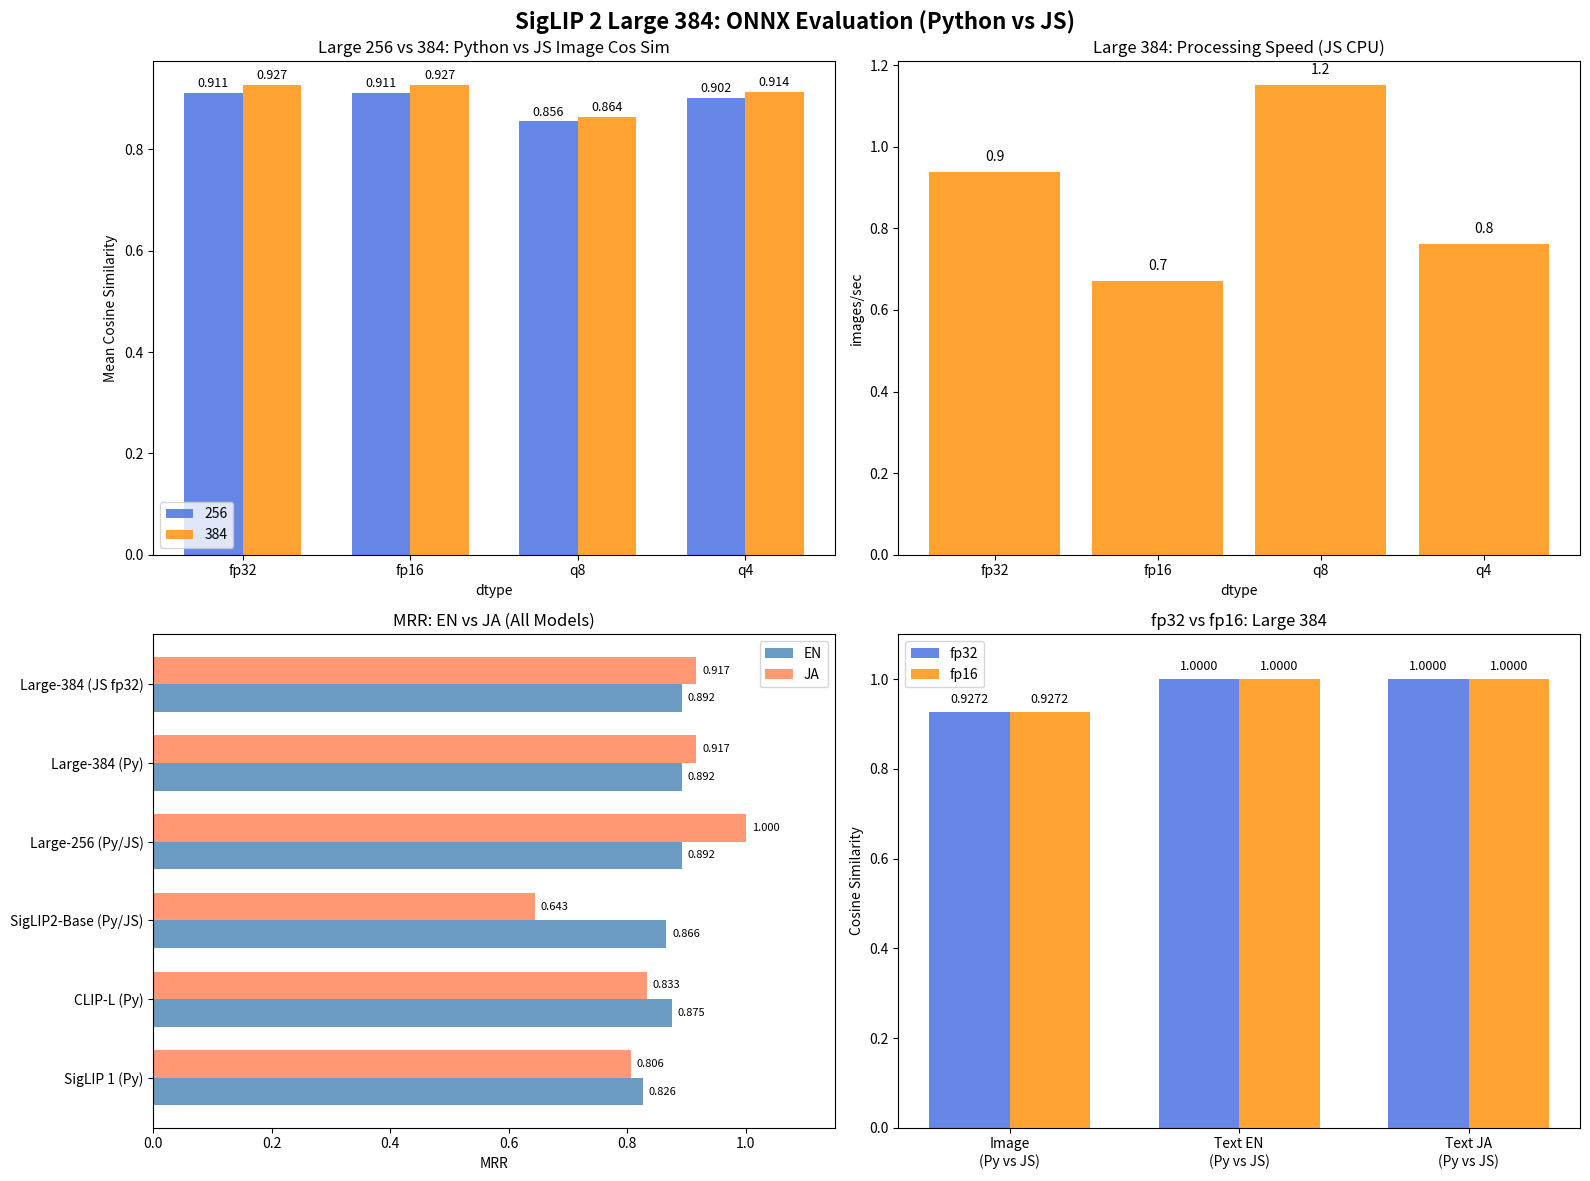

Saved: data/siglip2_large_384_onnx_evaluation.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 画像埋め込み cos sim by dtype (384 vs 256)
ax = axes[0, 0]
dtype_names = ['fp32', 'fp16', 'q8', 'q4']
means_384 = [comparison_results.get(d, {}).get('mean', 0) for d in dtype_names]
means_256 = [results_256['image_cos_sim'].get(d, 0) for d in dtype_names]
x = np.arange(len(dtype_names))
width = 0.35
bars1 = ax.bar(x - width/2, means_256, width, label='256', color='royalblue', alpha=0.8)
bars2 = ax.bar(x + width/2, means_384, width, label='384', color='darkorange', alpha=0.8)
ax.set_title('Large 256 vs 384: Python vs JS Image Cos Sim', fontsize=12)
ax.set_ylabel('Mean Cosine Similarity')
ax.set_xlabel('dtype')
ax.set_xticks(x)
ax.set_xticklabels(dtype_names)
ax.legend()
for bar, val in zip(bars1, means_256):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, means_384):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 2. 処理速度比較
ax = axes[0, 1]
times_384 = [comparison_results.get(d, {}).get('processing_time', 0) for d in dtype_names]
speeds_384 = [len(py_embeddings) / t if t > 0 else 0 for t in times_384]
speeds_256 = [len(py_embeddings) / results_256['speed']['js_fp32_time'],
              len(py_embeddings) / results_256['speed']['js_fp16_time'],
              0, 0]  # q8, q4 speed not stored
bars = ax.bar(dtype_names, speeds_384, color='darkorange', alpha=0.8, label='384')
ax.set_title('Large 384: Processing Speed (JS CPU)', fontsize=12)
ax.set_ylabel('images/sec')
ax.set_xlabel('dtype')
for bar, val in zip(bars, speeds_384):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# 3. MRR 比較（256 vs 384 + 他モデル）
ax = axes[1, 0]
all_mrr = {
    "SigLIP 1 (Py)": {"EN": 0.8264, "JA": 0.8056},
    "CLIP-L (Py)": {"EN": 0.875, "JA": 0.8333},
    "SigLIP2-Base (Py/JS)": {"EN": 0.8661, "JA": 0.6435},
    "Large-256 (Py/JS)": {"EN": 0.8917, "JA": 1.0},
    "Large-384 (Py)": {"EN": py_en, "JA": py_ja},
}
if 'fp32' in js_search_results:
    all_mrr["Large-384 (JS fp32)"] = {"EN": js_search_results['fp32']['EN'], "JA": js_search_results['fp32']['JA']}

model_names = list(all_mrr.keys())
ja_mrrs = [all_mrr[m]['JA'] for m in model_names]
en_mrrs = [all_mrr[m]['EN'] for m in model_names]
y = np.arange(len(model_names))
height = 0.35
ax.barh(y - height/2, en_mrrs, height, label='EN', color='steelblue', alpha=0.8)
ax.barh(y + height/2, ja_mrrs, height, label='JA', color='coral', alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(model_names)
ax.set_xlabel('MRR')
ax.set_title('MRR: EN vs JA (All Models)', fontsize=12)
ax.set_xlim(0, 1.15)
ax.legend()
for i, (en_v, ja_v) in enumerate(zip(en_mrrs, ja_mrrs)):
    ax.text(en_v + 0.01, i - height/2, f'{en_v:.3f}', va='center', fontsize=8)
    ax.text(ja_v + 0.01, i + height/2, f'{ja_v:.3f}', va='center', fontsize=8)

# 4. fp16 vs fp32 比較（384）
ax = axes[1, 1]
categories_chart = ['Image\n(Py vs JS)', 'Text EN\n(Py vs JS)', 'Text JA\n(Py vs JS)']
fp32_vals = [
    comparison_results.get('fp32', {}).get('mean', 0),
    text_sims_results.get('fp32', {}).get('en', 0),
    text_sims_results.get('fp32', {}).get('ja', 0),
]
fp16_vals = [
    comparison_results.get('fp16', {}).get('mean', 0),
    text_sims_results.get('fp16', {}).get('en', 0),
    text_sims_results.get('fp16', {}).get('ja', 0),
]
x = np.arange(len(categories_chart))
width = 0.35
ax.bar(x - width/2, fp32_vals, width, label='fp32', color='royalblue', alpha=0.8)
ax.bar(x + width/2, fp16_vals, width, label='fp16', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories_chart)
ax.set_ylabel('Cosine Similarity')
ax.set_title('fp32 vs fp16: Large 384', fontsize=12)
ax.legend()
ax.set_ylim(0, 1.1)
for i, (v32, v16) in enumerate(zip(fp32_vals, fp16_vals)):
    if v32 > 0: ax.text(i - width/2, v32 + 0.02, f'{v32:.4f}', ha='center', fontsize=9)
    if v16 > 0: ax.text(i + width/2, v16 + 0.02, f'{v16:.4f}', ha='center', fontsize=9)

plt.suptitle('SigLIP 2 Large 384: ONNX Evaluation (Python vs JS)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/siglip2_large_384_onnx_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/siglip2_large_384_onnx_evaluation.png')

## 11. 結果の保存

In [17]:
output_data = {
    "timestamp": datetime.now().isoformat(),
    "python_model": PYTHON_MODEL,
    "js_model": JS_MODEL,
    "embedding_dim": EMBEDDING_DIM,
    "resolution": 384,
    "image_comparison": comparison_results,
    "quantization_comparison": quant_comparison if 'quant_comparison' in dir() else {},
    "text_similarity": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in text_sims_results.items()},
    "search_mrr_python": {"EN": float(py_en), "JA": float(py_ja), "Overall": float(py_overall)},
    "search_mrr_js": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in js_search_results.items()},
}

output_path = Path("../data/evaluations") / f"siglip2_large_384_onnx_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/siglip2_large_384_onnx_2026-02-17.json


## 12. GPU メモリクリーンアップ

In [18]:
del embedder
del all_images

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

### 1. 画像埋め込み: Python vs JS コサイン類似度

| dtype | 384 | 256 | 差分 |
|:------|:---:|:---:|:----:|
| **fp32** | **0.927** | 0.912 | **+0.016** |
| **fp16** | **0.927** | 0.912 | **+0.016** |
| q8 | 0.864 | 0.856 | +0.009 |
| q4 | 0.914 | 0.902 | +0.012 |

- **384 は全 dtype で 256 より Python-JS 互換性が高い**: 解像度が上がることで、PyTorch と ONNX Runtime の前処理差異が相対的に小さくなっている可能性
- **fp16 は fp32 と完全同一**: 384 でも fp16 の品質劣化なし（JS fp32 vs fp16: 1.000）
- q8 の劣化傾向は 256 と同様（0.864 vs fp32 の 0.927）

### 2. 量子化の内部比較（JS fp32 基準）

| 比較 | 384 | 256 |
|:-----|:---:|:---:|
| fp32 vs fp16 | **1.000** | 1.000 |
| fp32 vs q8 | 0.926 | 0.919 |
| fp32 vs q4 | 0.982 | 0.979 |

384 の方が量子化耐性がやや高い。

### 3. テキスト埋め込み: Python vs JS 完全一致

| dtype | EN | JA |
|:------|:---:|:---:|
| fp32 | **1.000** | **1.000** |
| fp16 | **1.000** | **1.000** |

256 と同様、テキスト埋め込みは完全一致。テキストモデルは画像解像度に依存しないため、同じ結果になるのは妥当。

### 4. テキスト→画像検索 MRR: 256 の方が優秀

| 環境 | 256 EN | 384 EN | 256 JA | 384 JA | 256 Overall | 384 Overall |
|:-----|:------:|:------:|:------:|:------:|:-----------:|:-----------:|
| Python | 0.892 | 0.892 | **1.000** | 0.917 | **0.928** | 0.900 |
| JS fp32 | 0.892 | 0.892 | **1.000** | 0.917 | **0.928** | 0.900 |
| JS fp16 | 0.892 | 0.892 | **1.000** | 0.917 | **0.928** | 0.900 |

**重要な発見**: 384 の JA MRR は **0.917** で、256 の **1.000** より低下した。

- 「夜の街」クエリが MRR 1.0 → 0.5 に低下（Top-1 が期待カテゴリ外になった）
- 高解像度は画像の細部を捉える一方、テキストとの意味的マッチングには必ずしも有利ではない
- EN MRR は同一（0.892）

### 5. 処理速度

| 環境 | 256 | 384 | 速度比 |
|:-----|:---:|:---:|:------:|
| Python (GPU) | 6.8 img/s | 6.1 img/s | 0.9x |
| JS fp32 (CPU) | 1.8 img/s | 0.9 img/s | **0.5x** |
| JS fp16 (CPU) | 1.3 img/s | 0.7 img/s | **0.5x** |

384 は 256 の約半分の速度。解像度が 256→384 で画素数 2.25 倍になるため妥当。

### 6. 256 vs 384 総合評価

| 指標 | 256 | 384 | 勝者 |
|:-----|:---:|:---:|:----:|
| 画像 Py-JS cos sim (fp32) | 0.912 | **0.927** | 384 |
| テキスト Py-JS cos sim | 1.000 | 1.000 | 同点 |
| JA MRR | **1.000** | 0.917 | **256** |
| EN MRR | 0.892 | 0.892 | 同点 |
| Overall MRR | **0.928** | 0.900 | **256** |
| JS 処理速度 | **1.8 img/s** | 0.9 img/s | **256** |
| ONNX モデルサイズ | 小さい | 大きい | **256** |

### 7. 結論

- **SigLIP 2 Large 256 を推奨**: MRR（特に JA）、速度、モデルサイズすべてで 256 が優位
- 384 は画像の Py-JS 互換性がやや高いが、検索品質（最も重要な指標）では 256 に劣る
- 384 の利点が活きるのは、画像の細部が重要なタスク（物体検出の前段等）に限定される可能性
- **テキスト→画像検索用途では、256 版が最適解**